# Active EMI Suppression — gel experiment demo (Python)

Python port of `demo_gel_experiment.m`. Demonstrates Active EMI Suppression (AES)
on **gel phantom** data acquired during microwave ablation on a 3T scanner.

**Pipeline:** noise decorrelation → AES → GRAPPA → adaptive (Walsh) coil combine.

**Three reconstructions are compared:**

| Variable | Meaning |
|----------|---------|
| `imCC_unc`       | Uncorrected |
| `imCC_decor`     | Baseline (noise decorrelation only) |
| `imCC_decor_aes` | Proposed AES (decorrelation → AES) |

Inputs from `../data/gel_data.mat`: `kdata_rx/aux` (primary/aux k-space),
`acs_rx/aux` (calibration), `noise_rx/aux` (pre-scan noise).

> GRAPPA uses `pygrappa.mdgrappa` (the plain `grappa` half-fills k-space in this
> pygrappa version). Coil combine is Walsh adaptive (complex, phase preserved).
> Results are visually comparable to the MATLAB reference, not bit-identical.

*Port of MATLAB demo dated 2025-12-16.*

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

from aes import apply_decorrelation, perform_aes
from recon import reconstruct
from viz import imshow3

## 1. Load data & display dimensions

In [ ]:
d = loadmat('../data/gel_data.mat')
kdata_rx, kdata_aux = d['kdata_rx'], d['kdata_aux']     # primary / auxiliary k-space
acs_rx,   acs_aux   = d['acs_rx'],   d['acs_aux']       # GRAPPA calibration
noise_rx, noise_aux = d['noise_rx'], d['noise_aux']     # pre-scan noise

Nkx, Nky, Nch_img = kdata_rx.shape
Nch_emi = kdata_aux.shape[2]
print('------------------------------------------------')
print('Data loaded. Dimensions:')
print(f'   > Primary coil (Nkx, Nky, Ch): [{Nkx}, {Nky}, {Nch_img}]')
print(f'   > Aux coil     (Nkx, Nky, Ch): [{Nkx}, {Nky}, {Nch_emi}]')
print('------------------------------------------------')

------------------------------------------------
Data loaded. Dimensions:
   > Primary coil (Nkx, Nky, Ch): [256, 127, 12]
   > Aux coil     (Nkx, Nky, Ch): [256, 127, 18]
------------------------------------------------


## 2. Processing

### Step 1 — noise decorrelation (kdata AND acs, primary AND aux)

In [3]:
kdata_rx_decor  = apply_decorrelation(kdata_rx,  noise_rx)
kdata_aux_decor = apply_decorrelation(kdata_aux, noise_aux)
acs_rx_decor    = apply_decorrelation(acs_rx,    noise_rx)
acs_aux_decor   = apply_decorrelation(acs_aux,   noise_aux)
print('Step 1: noise decorrelation done.')

Step 1: noise decorrelation done.


### Step 2 — Active EMI Suppression (run on kdata and acs separately)

In [4]:
kdata_rx_decor_aes = perform_aes(kdata_rx_decor, kdata_aux_decor)
acs_rx_decor_aes   = perform_aes(acs_rx_decor,   acs_aux_decor)
print('Step 2: AES done.')

Step 2: AES done.


### Step 3 — GRAPPA reconstruction + Walsh coil combine

`reconstruct` returns `(im, imCC)`: coil-resolved image and adaptive coil-combined image.

In [5]:
# Uncorrected
im_unc,       imCC_unc       = reconstruct(kdata_rx,           acs_rx,           method='grappa', combine='adaptive')
# Baseline (decorrelation only)
im_decor,     imCC_decor     = reconstruct(kdata_rx_decor,     acs_rx_decor,     method='grappa', combine='adaptive')
# Proposed AES (decorrelation -> AES)
im_decor_aes, imCC_decor_aes = reconstruct(kdata_rx_decor_aes, acs_rx_decor_aes, method='grappa', combine='adaptive')
print('Step 3: GRAPPA + Walsh combine done. imCC shape:', imCC_decor_aes.shape)

Step 3: GRAPPA + Walsh combine done. imCC shape: (256, 127)


## 3. Check results

### Plot 1 — k-space comparison (sampled lines only)

Baseline vs proposed AES vs their complex difference (the EMI that AES removed), shown as an all-channel montage.

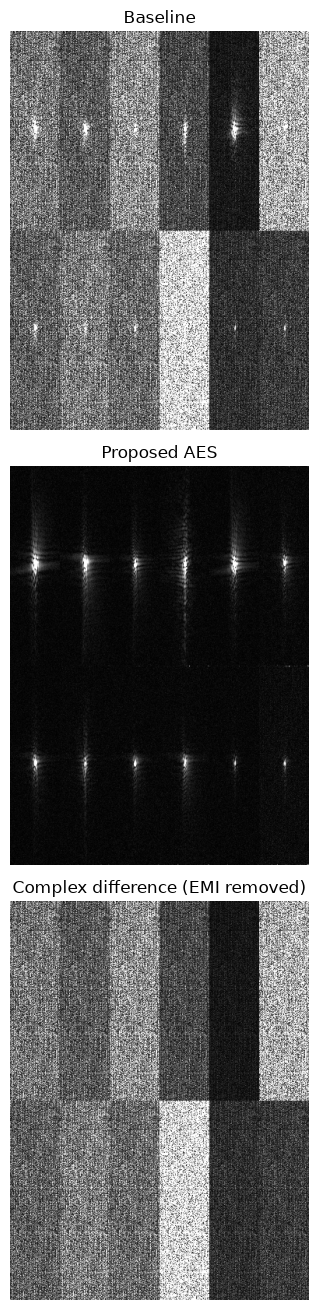

In [6]:
kdata_diff = kdata_rx_decor - kdata_rx_decor_aes
montage = (2, 6)                 # (rows, cols) for the 12 primary channels
kw = dict(vrange=(0, 1e-4), shape=montage)

# show only the acquired (non-zero-filled) PE lines, like the MATLAB demo
samp = ~np.all(kdata_rx_decor[:, :, 0] == 0, axis=0)

fig, ax = plt.subplots(3, 1, figsize=(2.2*montage[1], 2.2*montage[0]*3))
imshow3(np.abs(kdata_rx_decor[:, samp, :]),     **kw, ax=ax[0], title='Baseline')
imshow3(np.abs(kdata_rx_decor_aes[:, samp, :]), **kw, ax=ax[1], title='Proposed AES')
imshow3(np.abs(kdata_diff[:, samp, :]),         **kw, ax=ax[2], title='Complex difference (EMI removed)')
plt.tight_layout(); plt.show()

### Plot 2 — single-coil images (rotated 90° per paper convention)

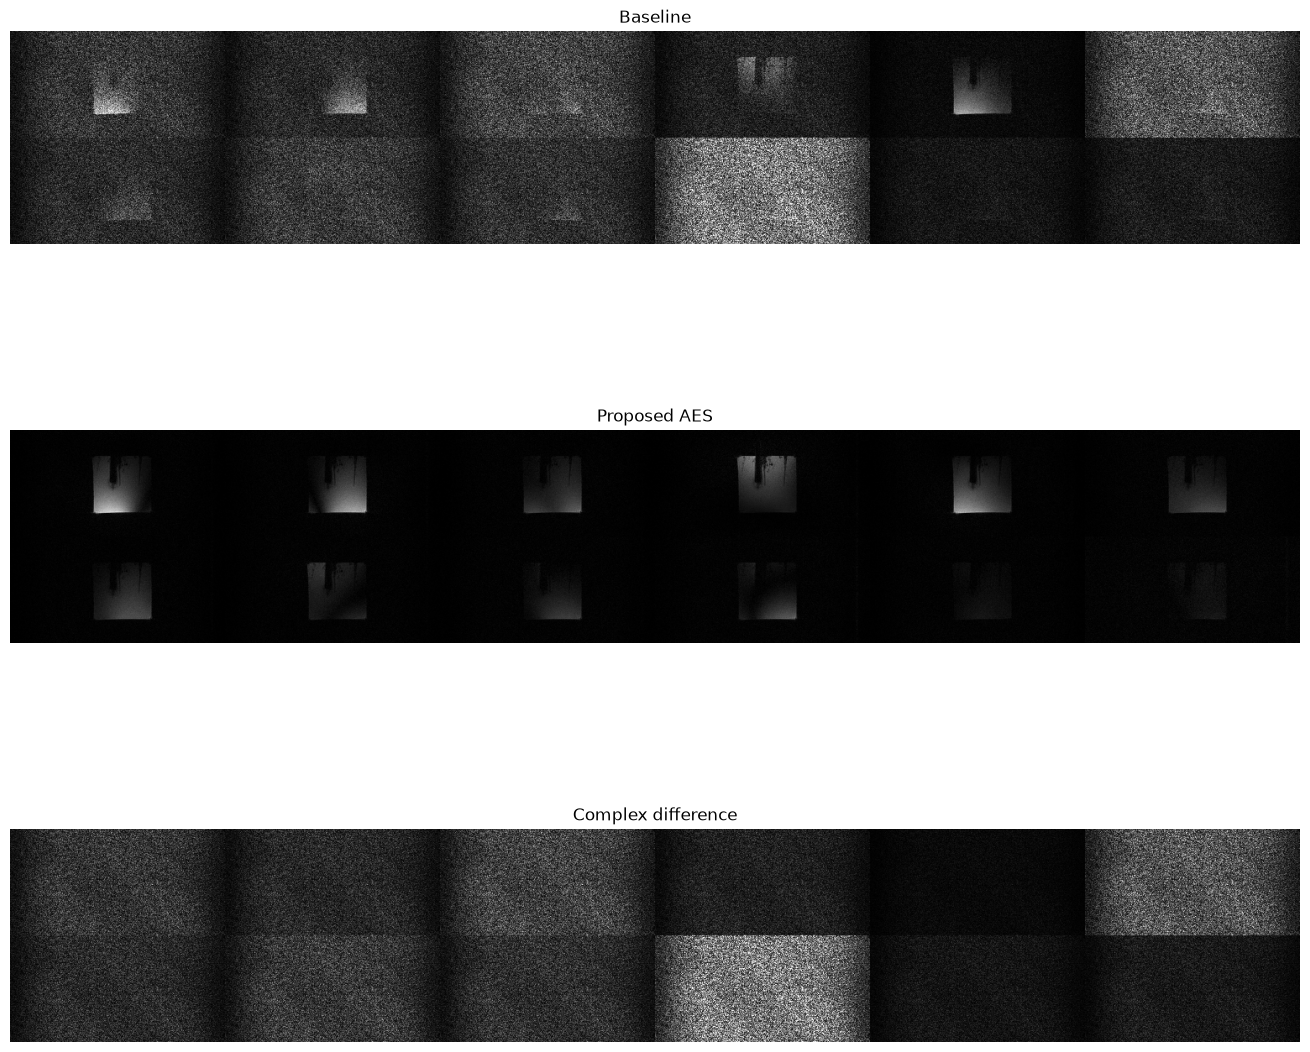

In [7]:
im_diff = im_decor - im_decor_aes
kw = dict(vrange=(0, 1e-6), shape=(2, 6))

fig, ax = plt.subplots(3, 1, figsize=(2.2*(2, 6)[1], 2.2*(2, 6)[0]*3))
imshow3(np.rot90(np.abs(im_decor),     axes=(0, 1)), **kw, ax=ax[0], title='Baseline')
imshow3(np.rot90(np.abs(im_decor_aes), axes=(0, 1)), **kw, ax=ax[1], title='Proposed AES')
imshow3(np.rot90(np.abs(im_diff),      axes=(0, 1)), **kw, ax=ax[2], title='Complex difference')
plt.tight_layout(); plt.show()

### Plot 3 — coil-combined images: magnitude (top) & phase (bottom)

Phase is preserved by the Walsh combine, so it is usable for PRF-shift thermometry.

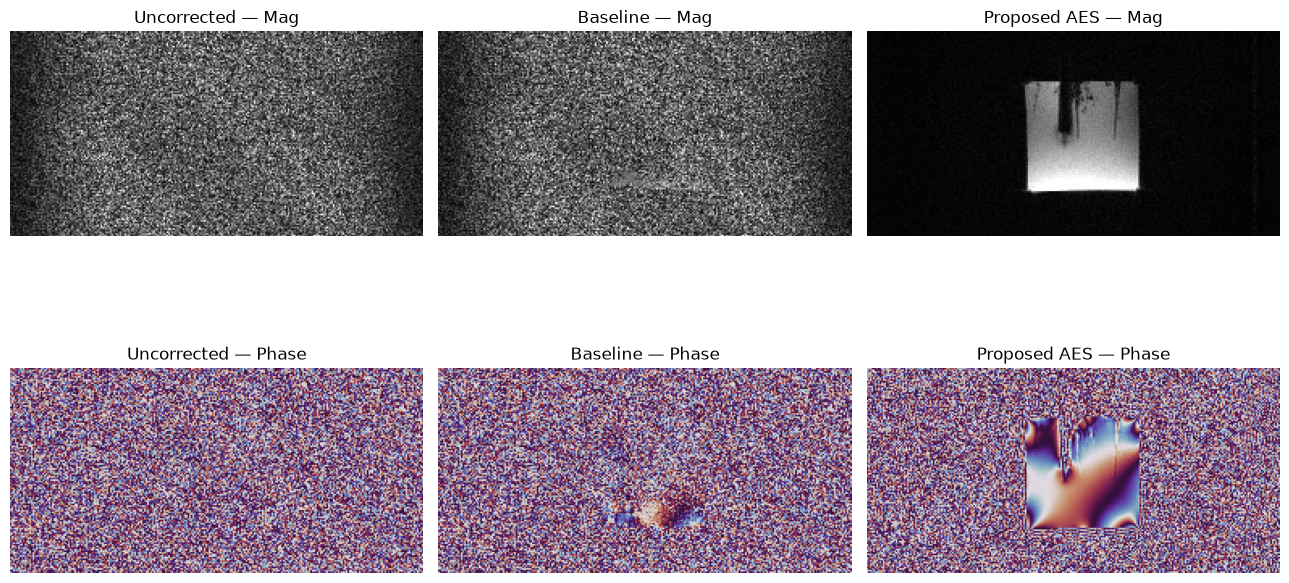

In [8]:
cases = [('Uncorrected', imCC_unc), ('Baseline', imCC_decor), ('Proposed AES', imCC_decor_aes)]

fig, ax = plt.subplots(2, 3, figsize=(13, 8))
for col, (title, cc) in enumerate(cases):
    ax[0, col].imshow(np.rot90(np.abs(cc)),   cmap='gray',     vmin=0, vmax=0.7)
    ax[0, col].set_title(f'{title} — Mag'); ax[0, col].axis('off')
    ax[1, col].imshow(np.rot90(np.angle(cc)), cmap='twilight', vmin=-np.pi, vmax=np.pi)
    ax[1, col].set_title(f'{title} — Phase'); ax[1, col].axis('off')
plt.tight_layout(); plt.show()